<div style="text-align: center;">

# Postal-Code Hazard Screening: Spain

</div>

This notebook shows how to run a point-based hazard screening workflow for a Spanish postal code. It starts from a postal-code polygon, samples representative points inside that polygon, requests hazard intensity curves from the Alpha-Klima API, and then summarizes the results into maps, return-period tables, and simple distribution charts.

The workflow is intentionally methodological. It is not a portfolio loss model and it does not apply asset-specific vulnerability curves. Instead, it demonstrates how to inspect the hazard signal inside an area before deciding whether a more detailed asset-impact workflow is needed.

The workflow is:

1. load credentials, dependencies, and plotting helpers,
2. inspect the hazard sources available from the API,
3. load the Spanish postal-code geometries,
4. sample points inside one postal-code polygon,
5. request point-level hazard curves,
6. parse the response into analysis tables,
7. summarize and visualize return-period intensity and expected annual intensity.

The example uses postal code `41010` in Seville. Users can change the postal code, number of sampled points, hazards, scenarios, and years in the configuration cells below.

## 1. Setup

When you run the notebook for the first time, select `.venv` as the interpreter. If you are unable to find the `.venv` interpreter, please follow the *Setup* instructions in the `README.md` to set it up.

### 1.1 Objective and Scope

This notebook screens hazard intensity inside a postal-code boundary. The core idea is simple:

- choose a postal-code polygon;
- sample points inside it;
- request hazard intensity curves at those points;
- summarize the returned curves into tables and figures.

**The output is useful for exploratory research and insurance screening**. It should not be interpreted as a building-level loss estimate because no building inventory, asset value, or vulnerability function is applied.

### 1.2 Imports

The notebook uses a mix of geospatial, numerical, plotting, and API packages:

* `geopandas` and `shapely` load postal-code polygons and sample points inside them.
* `numpy` and `pandas` handle numerical operations and tabular results.
* `plotly` creates maps, curves, and distribution charts.
* `requests` sends HTTPS requests to the Alpha-Klima API.
* `python-dotenv` reads API credentials from the local environment.

In [1]:
import os

import geopandas as gpd
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import requests
from dotenv import load_dotenv
from shapely.geometry import Point
from shapely.prepared import prep

In [2]:
# Ensure Plotly figures render both interactively and in static notebook viewers.
import plotly.io as pio

pio.renderers.default = "notebook+png"

In [3]:
_ = load_dotenv("../../.env")
API_KEY = os.environ.get("ALPHA_KLIMA_API_KEY")
API_BASE = os.environ.get("ALPHA_KLIMA_API_BASE_URL", "").rstrip("/")
HEADERS = {"X-API-Key": API_KEY, "Accept": "application/json"}

assert API_KEY and API_BASE, "Set ALPHA_KLIMA_API_KEY and ALPHA_KLIMA_API_BASE_URL in ../../.env"

## 2. Configure the Exercise

### 2.1 Available Hazard Sources

Before building a hazard request, it is useful to ask the API which hazards, indicators, scenarios, years, and asset types are available. This is a discovery step. It does not calculate risk; it helps the user choose valid request parameters.

The request below uses the `ECB_SCORES` use case and asks for the available source catalogue. The table then reshapes the nested response so it is easier to scan in the notebook.

In [4]:
SOURCE_REQUEST = {
    "include_all": False,
    "use_case_id": "ECB_SCORES",
    "selected_hazards_list": [],
}

available_sources_response = requests.post(
    url=f"{API_BASE}/api/get_available_sources",
    json=SOURCE_REQUEST,
    headers=HEADERS,
)
available_sources_response.raise_for_status()
available_sources = available_sources_response.json()

In [5]:
def available_sources_to_table(available_sources: dict[str, dict]) -> pd.DataFrame:
    "Flatten the available-source catalogue into one row per hazard indicator."
    rows = []

    for hazard, indicators in available_sources["hazards"].items():
        for indicator, available_data in indicators.items():
            scenarios_and_years = [
                {"scenario": entry["id"], "years": entry["years"]}
                for entry in available_data["scenarios"]
            ]

            rows.append(
                {
                    "hazard": hazard,
                    "indicator": indicator,
                    "scenario_years": scenarios_and_years,
                    "asset_types": available_data["available_for_assets_type"],
                }
            )

    return pd.DataFrame(rows)

In [6]:
available_sources_to_table(available_sources)

,hazard,indicator,scenario_years,asset_types
0,RiverineInundation,flood_depth,"[{'scenario': 'historical', 'years': [1985]}, ...","[UtilityAsset, OilGasAsset, RealEstateAsset, T..."
1,CoastalInundation,flood_depth,"[{'scenario': 'historical', 'years': [1971]}, ...","[UtilityAsset, OilGasAsset, RealEstateAsset, T..."
2,Fire,fire_probability,"[{'scenario': 'historical', 'years': [2010]}, ...","[UtilityAsset, OilGasAsset, RealEstateAsset, T..."
3,Hail,days/above/5cm,"[{'scenario': 'ssp126', 'years': [2020, 2030, ...","[UtilityAsset, OilGasAsset, RealEstateAsset, T..."
4,Hail,hail_probability,"[{'scenario': 'historical', 'years': [1985]}, ...","[RealEstateAsset, TelecommunicationAsset, Infr..."
5,Wind,max_speed,"[{'scenario': 'historical', 'years': [2010]}, ...","[UtilityAsset, OilGasAsset, RealEstateAsset, T..."
6,Wind,wind_speed/3s,"[{'scenario': 'historical', 'years': [1999]}]","[RealEstateAsset, TelecommunicationAsset, Powe..."
7,Wind,windstorm_probability,"[{'scenario': 'historical', 'years': [1971]}, ...","[RealEstateAsset, TelecommunicationAsset, Infr..."
8,Landslide,landslide_susceptability,"[{'scenario': 'historical', 'years': [2018]}]","[UtilityAsset, OilGasAsset, RealEstateAsset, T..."
9,Subsidence,subsidence_susceptability,"[{'scenario': 'historical', 'years': [1980]}]","[RealEstateAsset, TelecommunicationAsset, Infr..."


### 2.2 Load Postal-Code Geometries

The postal-code boundaries are loaded from `../../resources/codigos_postales/codigos_postales.shp`. The example shapefile uses EPSG:4258, a latitude/longitude coordinate reference system commonly used for European geospatial data.

The next cell prints the columns and coordinate reference system so the user can confirm that the expected postal-code field and geometry are present before sampling points.

In [7]:
POSTAL_CODE_SHAPEFILE = "../../resources/codigos_postales/codigos_postales.shp"
POSTCODE_COLUMN = "COD_POSTAL"

gdf = gpd.read_file(POSTAL_CODE_SHAPEFILE)

print("Postal-code columns:", list(gdf.columns))
print("Geometry CRS:", gdf.crs)

Postal-code columns: ['ID_CP', 'COD_POSTAL', 'ALTA_DB', 'CODIGO_INE', 'geometry']
Geometry CRS: EPSG:4258


## 3. Postal-Code Selection and Point Sampling

This section selects one postal code and generates representative points inside its polygon. The example uses postal code `41010` in Seville, near the Guadalquivir River.

### Why Project to Meters Before Sampling?

The shapefile is stored in EPSG:4258, where coordinates are measured in degrees. Random sampling in degrees can distort distances and areas. To make the sampling spatially consistent, the helper temporarily projects the geometry to EPSG:25830, a metric CRS for Spain. The sampled points are then converted back to EPSG:4326 latitude/longitude before being sent to the hazard API.

The sampled points are not buildings. They are representative locations inside the postal-code polygon, used to understand how hazard intensity varies across the area.

In [8]:
def sample_points_per_postcode(
    postal_codes: gpd.GeoDataFrame,
    postcode: str | int,
    *,
    postcode_col: str = "COD_POSTAL",
    n_points: int = 50,
    source_crs: str = "EPSG:4258",     # Spanish shapefile CRS (ETRS89)
    sampling_crs: str = "EPSG:25830",  # metric CRS for Spain (ETRS89 / UTM 30N)
    out_crs: str = "EPSG:4326",        # latitude/longitude for hazard API requests
    seed: int = 42,
    margin_m: float = 0.0,
    batch_mult: int = 10,
    batch_hard_cap: int = 50_000,
    max_iter_factor: int = 60,
) -> pd.DataFrame:
    """
    Sample points inside one postal-code polygon and return lat/lon in EPSG:4326.
    """

    if postal_codes.crs is None:
        raise ValueError("GeoDataFrame has no CRS.")
    if str(postal_codes.crs).upper() != source_crs.upper():
        raise ValueError(f"Unexpected CRS: {postal_codes.crs}. Expected {source_crs}.")

    if postcode_col not in postal_codes.columns:
        raise ValueError(f"Column not found: '{postcode_col}'. Columns: {list(postal_codes.columns)}")

    postcode_str = str(postcode).strip()
    if postcode_str.isdigit() and len(postcode_str) < 5:
        postcode_str = postcode_str.zfill(5)

    postal_code_values = postal_codes[postcode_col].astype(str).str.strip()
    postal_code_values = postal_code_values.apply(lambda s: s.zfill(5) if s.isdigit() and len(s) < 5 else s)

    match = postal_codes.loc[postal_code_values == postcode_str, "geometry"]
    if match.empty:
        raise ValueError(f"Postal code {postcode_str} not found in column {postcode_col}.")

    geom = match.iloc[0]
    if geom is None or geom.is_empty:
        raise ValueError(f"Empty geometry for postal code {postcode_str}.")

    if not geom.is_valid:
        geom = geom.buffer(0)

    geom_m = gpd.GeoSeries([geom], crs=source_crs).to_crs(sampling_crs).iloc[0]
    geom_prep = prep(geom_m)

    minx, miny, maxx, maxy = geom_m.bounds
    minx -= margin_m
    miny -= margin_m
    maxx += margin_m
    maxy += margin_m

    rng = np.random.default_rng(seed)
    batch_size = min(max(n_points * batch_mult, 1000), batch_hard_cap)
    max_iter = max(n_points * max_iter_factor, 2000)

    sampled_points_m = []
    points_tested = 0
    while len(sampled_points_m) < n_points and points_tested < max_iter:
        xs = rng.uniform(minx, maxx, size=batch_size)
        ys = rng.uniform(miny, maxy, size=batch_size)
        candidates = [Point(x, y) for x, y in zip(xs, ys)]
        sampled_points_m.extend([point for point in candidates if geom_prep.contains(point)])
        points_tested += batch_size

    if len(sampled_points_m) < n_points:
        raise RuntimeError(
            f"Unable to sample {n_points} points in postal code {postcode_str} "
            f"(only {len(sampled_points_m)} were sampled). Try increasing batch_mult/max_iter_factor "
            "or inspect the source geometry."
        )

    sampled_points_m = sampled_points_m[:n_points]
    sampled_points_4326 = gpd.GeoSeries(sampled_points_m, crs=sampling_crs).to_crs(out_crs)

    return pd.DataFrame({
        "lat": sampled_points_4326.y,
        "lon": sampled_points_4326.x,
    })

In [9]:
POSTCODE = "41010"
N_SAMPLE_POINTS = 50

points = sample_points_per_postcode(
    gdf,
    POSTCODE,
    postcode_col=POSTCODE_COLUMN,
    n_points=N_SAMPLE_POINTS,
)

## 4. Build the Hazard Request

The hazard-data API expects a list of request items. Each item represents one hazard, indicator, scenario, and year for the same set of sampled points.

In this example, the notebook requests:

- riverine flood depth for historical, mid-century, and late-century climate cases;
- European 3-second gust wind speed for the historical wind field.

The sampled point order matters. The API returns one intensity curve per input point in the same order, which lets the notebook join the response back to the `points` table without spatial matching.

In [10]:
lons = points["lon"].tolist()
lats = points["lat"].tolist()

HAZARD_REQUEST_ITEMS = []

FLOOD_CASES = [
    ("historical", 1971),
    ("rcp4p5", 2035),
    ("rcp4p5", 2085),
    ("rcp8p5", 2035),
    ("rcp8p5", 2085),
]

for scenario, year in FLOOD_CASES:
    HAZARD_REQUEST_ITEMS.append({
        "request_item_id": f"riverine_{scenario}_{year}",
        "event_type": "RiverineInundation",
        "longitudes": lons,
        "latitudes": lats,
        "year": year,
        "scenario": scenario,
        "indicator_id": "flood_depth",
    })

HAZARD_REQUEST_ITEMS.append({
    "request_item_id": "wind_historical_1999",
    "event_type": "Wind",
    "longitudes": lons,
    "latitudes": lats,
    "year": 1999,
    "scenario": "historical",
    "indicator_id": "wind_speed/3s",
})

hazard_request = {"items": HAZARD_REQUEST_ITEMS, "interpolation": "floor"}

### 4.1 Execute the Hazard Request

The request is sent to `/api/get_hazard_data`. This endpoint returns hazard intensity, not financial loss. For flood, the intensity values are depths at different return periods. For wind, they are gust-speed values for the requested wind field.

In [11]:
hazard_data_response = requests.post(
    url=f"{API_BASE}/api/get_hazard_data",
    json=hazard_request,
    headers=HEADERS,
)
hazard_data_response.raise_for_status()
hazard_data = hazard_data_response.json()

## 5. Parse the Response Into Return-Period Tables

The API returns one output item for each hazard/scenario/year request. Each output item contains an `intensity_curve_set`: a list of curves, one curve per sampled point.

For return-period hazards, each curve contains:

- `index_values`: return periods, such as 10, 30, 100, 300, and 1000 years;
- `intensities`: the hazard intensity associated with each return period.

For analysis, it is easier to reshape each response item into a wide table with columns such as `rp10`, `rp30`, `rp100`, `rp300`, and `rp1000`. The resulting tables keep the point latitude/longitude and add the hazard, indicator, scenario, and year metadata.

In [12]:
def return_periods_from_item(item: dict) -> list[float]:
    "Extract return periods from the first curve that contains index_values."
    for curve in item.get("intensity_curve_set", []):
        return_periods = curve.get("index_values", []) or []
        if return_periods:
            return [float(return_period) for return_period in return_periods]
    return []


def build_return_period_tables_by_item(
    items: list[dict],
    points: pd.DataFrame,
) -> dict[tuple[str, str, int], pd.DataFrame]:
    "Build one point-level return-period table per hazard/scenario/year item."
    base = points.reset_index(drop=True).copy()
    tables = {}

    for item in items:
        curves = item["intensity_curve_set"]
        event_type = item.get("hazard_type")
        scenario = item.get("scenario")
        year = int(item.get("year"))
        request_item_id = item.get("request_item_id")
        indicator = item.get("indicator_id") or item.get("model")

        if len(curves) != len(base):
            raise ValueError(
                f"{request_item_id}: {len(curves)} curves were received but {len(base)} points were expected."
            )

        return_periods = return_periods_from_item(item)
        if not return_periods:
            raise ValueError(f"{request_item_id}: index_values not found in any curve.")

        matrix = []
        for curve in curves:
            intensity_by_return_period = {
                float(return_period): float(intensity)
                for return_period, intensity in zip(
                    curve.get("index_values", []) or [],
                    curve.get("intensities", []) or [],
                )
            }
            matrix.append([
                intensity_by_return_period.get(return_period, np.nan)
                for return_period in return_periods
            ])

        arr = np.asarray(matrix, float)

        df = base.copy()
        df["request_item_id"] = request_item_id
        df["event_type"] = event_type
        df["indicator"] = indicator
        df["scenario"] = scenario
        df["year"] = year

        for j, return_period in enumerate(return_periods):
            if float(return_period).is_integer():
                col = f"rp{int(return_period)}"
            else:
                col = f"rp{str(return_period).replace('.', '_')}"
            df[col] = arr[:, j]

        key = (event_type, scenario, year)
        if key in tables:
            raise ValueError(f"Duplicated key: {key}. Revisit event_type, scenario, and year uniqueness.")
        tables[key] = df

    return tables

In [13]:
return_period_tables = build_return_period_tables_by_item(hazard_data["items"], points)

df_riverine_2035 = return_period_tables[("RiverineInundation", "rcp4p5", 2035)]

In [14]:
RP_COLUMNS = ["rp10", "rp30", "rp100", "rp300", "rp1000"]

# Basic point-level distribution summary for the selected flood slice.
df_riverine_2035[RP_COLUMNS].describe()

,rp10,rp30,rp100,rp300,rp1000
count,33.000000,37.000000,47.000000,40.000000,42.000000
mean,4.678988,4.710062,4.108138,5.132551,5.181657
std,2.985330,3.149857,3.505255,3.316296,3.423629
min,0.869600,0.057680,0.000000,0.075120,0.242900
25%,1.990000,2.405000,0.993750,2.715250,2.764750
50%,4.259000,4.356000,3.247000,4.643000,4.221500
75%,6.432000,6.844000,5.872000,7.648000,7.596250
max,10.680000,11.170000,11.660000,11.990000,12.300000


In [15]:
# Missing values by return period. Missing data should be reviewed before interpreting aggregates.
df_riverine_2035[RP_COLUMNS].isna().sum()

rp10      17
rp30      13
rp100      3
rp300     10
rp1000     8
dtype: int64

In [16]:
# Share of sampled points with zero intensity. For flood, this can mean no inundation at that point.
(df_riverine_2035[RP_COLUMNS] == 0).mean()

rp10      0.00
rp30      0.00
rp100     0.16
rp300     0.00
rp1000    0.00
dtype: float64

In [17]:
coverage = (1 - df_riverine_2035[RP_COLUMNS].isna().mean()) * 100
coverage

rp10      66.0
rp30      74.0
rp100     94.0
rp300     80.0
rp1000    84.0
dtype: float64

## 6. Map Point-Level Intensity

The first visual check is a map of one return-period intensity, such as `rp100`. This shows how the hazard signal varies inside the postal-code polygon.

For flood, a value of zero generally means the sampled point has no inundation in that return-period layer. Missing values should be interpreted more carefully because they can reflect data coverage rather than no hazard.

In [18]:
def plot_map_points(df: pd.DataFrame, value_col: str = "rp100", title: str | None = None):
    "Map sampled points colored by one hazard-intensity column."
    fig = px.scatter_map(
        df,
        lat="lat",
        lon="lon",
        color=value_col,
        hover_data=["lat", "lon", value_col],
        zoom=12,
        height=650,
    )
    center = {"lat": float(df["lat"].mean()), "lon": float(df["lon"].mean())}
    fig.update_layout(
        map_style="open-street-map",
        map_center=center,
        title=title or f"{value_col} per sampled point",
        margin=dict(l=0, r=0, t=50, b=0),
    )
    return fig

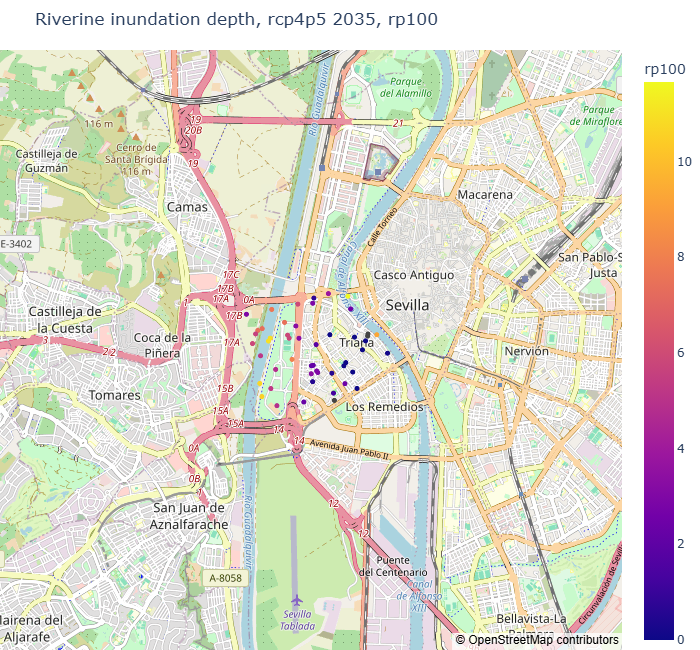

In [19]:
fig = plot_map_points(
    df_riverine_2035,
    "rp100",
    "Riverine inundation depth, rcp4p5 2035, rp100",
)
fig.show()

## 7. Aggregate the Return-Period Curve

The map shows point-level variation. The next chart summarizes all sampled points into one curve for the postal code.

For each return period, the notebook calculates:

- the median, shown as the central curve;
- the 10th to 90th percentile band, shown as the spatial spread across sampled points.

The x-axis uses a logarithmic scale because return periods are usually compared multiplicatively: 10, 30, 100, 300, and 1000 years.

In [20]:
def plot_aggregated_return_period_curve(
    df: pd.DataFrame,
    rp_list=(10, 30, 100, 300, 1000),
    title: str | None = None,
):
    "Plot median and p10-p90 intensity across sampled points for each return period."
    return_periods = np.array(rp_list, dtype=float)
    cols = [f"rp{int(return_period)}" for return_period in return_periods]

    values = df[cols].to_numpy(float)

    p10 = np.nanpercentile(values, 10, axis=0)
    p50 = np.nanpercentile(values, 50, axis=0)
    p90 = np.nanpercentile(values, 90, axis=0)

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=return_periods, y=p90, mode="lines", line=dict(width=0), showlegend=False, name="p90"))
    fig.add_trace(go.Scatter(x=return_periods, y=p10, mode="lines", line=dict(width=0), fill="tonexty", name="p10-p90"))
    fig.add_trace(go.Scatter(x=return_periods, y=p50, mode="lines+markers", name="median"))

    fig.update_layout(
        title=title or "Aggregated return-period curve",
        xaxis_title="Return period (years)",
        yaxis_title="Flood depth (m)",
        xaxis_type="log",
        height=450,
    )
    return fig

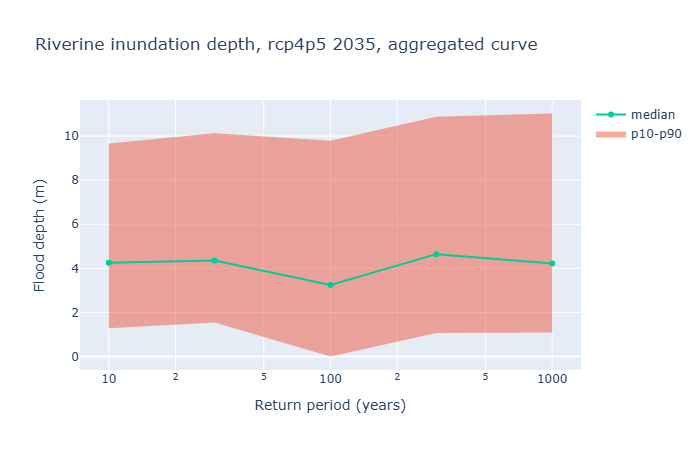

In [21]:
fig = plot_aggregated_return_period_curve(
    df_riverine_2035,
    title="Riverine inundation depth, rcp4p5 2035, aggregated curve",
)
fig.show()

## 8. Return-Period Aggregation Table

The chart is useful for interpretation, but a table is better for review and export. This section calculates point-level summary metrics for each return period:

- `mean`, `p50`, `p95`, and `max`, ignoring missing values;
- `share_gt0`, the fraction of sampled points with intensity greater than zero;
- `coverage`, the fraction of sampled points with available data;
- `n`, the number of sampled points included in the statistic.

`share_gt0` is especially useful for flood screening because it approximates how much of the sampled area has non-zero inundation in the selected layer.

In [22]:
def aggregate_return_period_stats(df: pd.DataFrame, rp_cols: list[str]) -> pd.DataFrame:
    "Return summary statistics by return-period column."
    rows = []
    n_total = len(df)

    for col in rp_cols:
        values = df[col].astype(float)
        valid_mask = ~np.isnan(values.to_numpy())

        if valid_mask.sum() == 0:
            rows.append({
                "rp": col,
                "mean": np.nan,
                "p50": np.nan,
                "p95": np.nan,
                "max": np.nan,
                "share_gt0": np.nan,
                "coverage": 0.0,
                "n": 0,
            })
            continue

        valid_values = values[valid_mask]

        rows.append({
            "rp": col,
            "mean": float(np.nanmean(valid_values)),
            "p50": float(np.nanpercentile(valid_values, 50)),
            "p95": float(np.nanpercentile(valid_values, 95)),
            "max": float(np.nanmax(valid_values)),
            "share_gt0": float(np.mean(valid_values > 0.0)),
            "coverage": float(valid_mask.sum() / n_total),
            "n": int(valid_mask.sum()),
        })

    return pd.DataFrame(rows)

In [23]:
rp_cols = sorted(
    [col for col in df_riverine_2035.columns if col.startswith("rp")],
    key=lambda col: float(col[2:].replace("_", ".")),
)

rp_stats = aggregate_return_period_stats(df_riverine_2035, rp_cols)
rp_stats

,rp,mean,p50,p95,max,share_gt0,coverage,n
0,rp10,4.678988,4.2590,9.9310,10.68,1.000000,0.66,33
1,rp30,4.710062,4.3560,10.4400,11.17,1.000000,0.74,37
2,rp100,4.108138,3.2470,10.8610,11.66,0.829787,0.94,47
3,rp300,5.132550,4.6430,11.2400,11.99,1.000000,0.80,40
4,rp1000,5.181657,4.2215,11.5275,12.30,1.000000,0.84,42


## 9. Expected Annual Intensity

Return-period tables describe selected event severities, but sometimes it is useful to summarize the whole curve into one scalar value per sampled point. This notebook uses a simple **Expected Annual Intensity** proxy, or EAI.

For a return period `RP` in years, annual exceedance probability is approximated as:

$$
p = \frac{1}{RP}
$$

The helper converts the curve from `I(RP)` to `I(p)` and integrates under the curve:

$$
\mathrm{EAI} \approx \int I(p)\,dp
$$

Because the API returns only a small set of return periods, the notebook uses the trapezoidal rule between available points. A value of `0.0` remains a real zero; missing values are ignored. At least two non-missing curve points are required.

EAI is a **hazard-severity proxy**, not a loss metric. It can help compare points or postal codes, but it does not include exposure, vulnerability, or euros.

In [24]:
def eai_from_row(row: pd.Series, rp_cols: list[str]) -> float:
    "Approximate expected annual intensity by integrating intensity over annual exceedance probability."
    pairs = []
    for col in rp_cols:
        value = row.get(col, np.nan)
        if pd.notna(value):
            return_period = float(col[2:].replace("_", "."))
            pairs.append((return_period, float(value)))

    if len(pairs) < 2:
        return np.nan

    return_periods = np.array([pair[0] for pair in pairs], dtype=float)
    intensities = np.array([pair[1] for pair in pairs], dtype=float)

    exceedance_probabilities = 1.0 / return_periods
    order = np.argsort(exceedance_probabilities)
    exceedance_probabilities = exceedance_probabilities[order]
    intensities = intensities[order]

    return float(np.trapezoid(intensities, exceedance_probabilities))


def aggregate_eai(df: pd.DataFrame, rp_cols: list[str]) -> dict:
    "Summarize expected annual intensity across sampled points."
    eai = df.apply(eai_from_row, axis=1, rp_cols=rp_cols)
    return {
        "eai_mean": float(np.nanmean(eai)),
        "eai_p50": float(np.nanpercentile(eai, 50)),
        "eai_p95": float(np.nanpercentile(eai, 95)),
        "eai_max": float(np.nanmax(eai)),
        "eai_coverage": float(np.mean(~np.isnan(eai))),
    }

In [25]:
df_riverine_2035 = df_riverine_2035.copy()
df_riverine_2035["eai"] = df_riverine_2035.apply(eai_from_row, axis=1, rp_cols=rp_cols)

eai_summary = aggregate_eai(df_riverine_2035, rp_cols)
eai_summary

{'eai_mean': 0.42384338475000016,
 'eai_p50': 0.37510175,
 'eai_p95': 1.0288266666666668,
 'eai_max': 1.101855,
 'eai_coverage': 0.8}

## 10. Distribution Views

The final charts show the distribution of sampled-point results inside the postal code.

The `rp100` histogram shows the spread of 100-year flood depths across sampled points. The EAI histogram summarizes the full return-period curve into one value per point. Together, these plots help explain spatial heterogeneity, the share of points with no hazard signal, and whether the postal-code result is driven by a few high-intensity locations.

In [26]:
def plot_return_period_distribution(df, rp_col="rp100", title=None):
    "Plot the distribution of one return-period intensity column."
    values = df[rp_col].astype(float)

    df_plot = df.loc[~values.isna(), [rp_col]].copy()
    fig = px.histogram(
        df_plot,
        x=rp_col,
        nbins=25,
        marginal="box",
        title=title or f"{rp_col} distribution (missing values excluded, zeros included)",
    )
    return fig

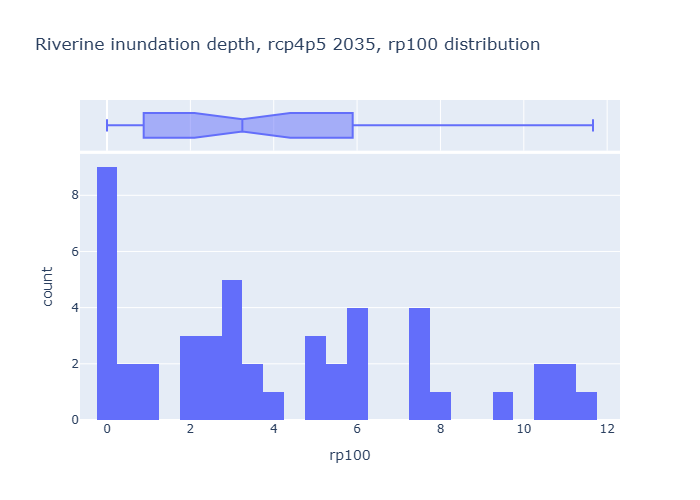

In [27]:
fig = plot_return_period_distribution(
    df_riverine_2035,
    "rp100",
    "Riverine inundation depth, rcp4p5 2035, rp100 distribution",
)
fig.show()

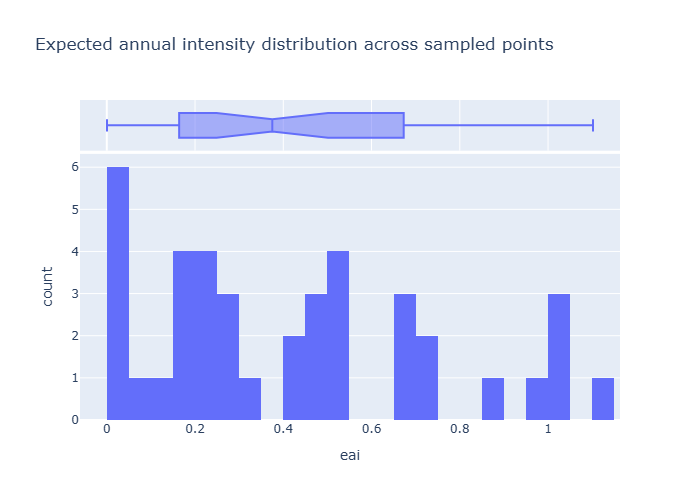

In [28]:
fig = px.histogram(
    df_riverine_2035.loc[~df_riverine_2035["eai"].isna(), :],
    x="eai",
    nbins=25,
    marginal="box",
    title="Expected annual intensity distribution across sampled points",
)
fig.show()